## Preprocess clinical

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

clinical = pd.read_csv('dataset/clinical.csv')
clinical.head()

,id,creation_datetime,patientID,original_patientID,sex,age,AJCC_stage,M_stage,LDH,OS_status,...,drug,BOR,BRAF_mut,brain_metastasis,immunotherapy_treatment,pre_MAPKi_treatment,CNA_data,SNV_data,GEX_data,source
0,1,2025-04-23 22:54:49.773923,BS_000,0,male,56,IV,NaN,normal,0.0,...,dabrafenib + trametinib,PD,V600E,no,no,no,no,yes,no,doi:10.3390/cancers12082224
1,2,2025-04-23 22:54:49.802003,BS_001,1,male,86,IV,NaN,normal,1.0,...,dabrafenib,SD,V600E,no,no,no,no,yes,no,doi:10.3390/cancers12082224
2,3,2025-04-23 22:54:49.807526,BS_002,2,female,47,IV,NaN,normal,0.0,...,dabrafenib + trametinib,CR,V600E,no,no,no,no,yes,no,doi:10.3390/cancers12082224
3,4,2025-04-23 22:54:49.813005,BS_003,3,female,50,IV,NaN,NaN,1.0,...,vemurafenib,PD,V600E,no,no,no,no,yes,no,doi:10.3390/cancers12082224
4,5,2025-04-23 22:54:49.818403,BS_004,4,female,47,IV,NaN,elevated,1.0,...,dabrafenib + trametinib,PD,V600K,no,no,no,no,yes,no,doi:10.3390/cancers12082224


In [95]:
clinical.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 417 entries, 0 to 416
Data columns (total 23 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       417 non-null    int64  
 1   creation_datetime        417 non-null    object 
 2   patientID                417 non-null    object 
 3   original_patientID       417 non-null    object 
 4   sex                      417 non-null    object 
 5   age                      417 non-null    int64  
 6   AJCC_stage               417 non-null    object 
 7   M_stage                  280 non-null    object 
 8   LDH                      274 non-null    object 
 9   OS_status                259 non-null    float64
 10  OS_month                 257 non-null    float64
 11  PFS_status               415 non-null    float64
 12  PFS_month                417 non-null    float64
 13  drug                     416 non-null    object 
 14  BOR                      4

In [96]:
clinical = clinical.drop(['id', 'creation_datetime', 'original_patientID', 'OS_status', 'OS_month', 'immunotherapy_treatment', 'CNA_data', 'SNV_data', 'GEX_data'], axis=1)
clinical.head()

,patientID,sex,age,AJCC_stage,M_stage,LDH,PFS_status,PFS_month,drug,BOR,BRAF_mut,brain_metastasis,pre_MAPKi_treatment,source
0,BS_000,male,56,IV,NaN,normal,1.0,30.5,dabrafenib + trametinib,PD,V600E,no,no,doi:10.3390/cancers12082224
1,BS_001,male,86,IV,NaN,normal,0.0,24.1,dabrafenib,SD,V600E,no,no,doi:10.3390/cancers12082224
2,BS_002,female,47,IV,NaN,normal,0.0,14.1,dabrafenib + trametinib,CR,V600E,no,no,doi:10.3390/cancers12082224
3,BS_003,female,50,IV,NaN,NaN,1.0,1.6,vemurafenib,PD,V600E,no,no,doi:10.3390/cancers12082224
4,BS_004,female,47,IV,NaN,elevated,1.0,11.9,dabrafenib + trametinib,PD,V600K,no,no,doi:10.3390/cancers12082224


In [97]:
def get_pfs_label(row):
    months = row['PFS_month']
    event = row['PFS_status']
    
    if months >= 18:
        return 2  # Long responder
    elif months < 6 and event == 1:
        return 0   # Non responder
    elif 6 <= months < 18 and event == 1:
        return 1 # Intermediate
    else:
        return np.nan   # Undetermind
    
clinical['pfs_label'] = clinical.apply(get_pfs_label, axis=1)
clinical

,patientID,sex,age,AJCC_stage,M_stage,LDH,PFS_status,PFS_month,drug,BOR,BRAF_mut,brain_metastasis,pre_MAPKi_treatment,source,pfs_label
0,BS_000,male,56,IV,NaN,normal,1.0,30.5,dabrafenib + trametinib,PD,V600E,no,no,doi:10.3390/cancers12082224,2.0
1,BS_001,male,86,IV,NaN,normal,0.0,24.1,dabrafenib,SD,V600E,no,no,doi:10.3390/cancers12082224,2.0
2,BS_002,female,47,IV,NaN,normal,0.0,14.1,dabrafenib + trametinib,CR,V600E,no,no,doi:10.3390/cancers12082224,NaN
3,BS_003,female,50,IV,NaN,NaN,1.0,1.6,vemurafenib,PD,V600E,no,no,doi:10.3390/cancers12082224,0.0
4,BS_004,female,47,IV,NaN,elevated,1.0,11.9,dabrafenib + trametinib,PD,V600K,no,no,doi:10.3390/cancers12082224,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
412,HL_40,male,47,IV,M1C,NaN,1.0,3.0,vemurafenib,PR,V600E,no,no,doi:10.1016/j.cell.2015.07.061,0.0
413,HL_41,male,39,IV,M1A,NaN,1.0,4.0,vemurafenib,PR,V600E,no,no,doi:10.1016/j.cell.2015.07.061,0.0
414,HL_42,male,84,IV,M1C,NaN,1.0,8.0,dabrafenib,PR,V600E,no,no,doi:10.1016/j.cell.2015.07.061,1.0
415,HL_43,female,41,IV,M1C,NaN,1.0,10.9,vemurafenib,PR,V600E,no,no,doi:10.1016/j.cell.2015.07.061,1.0


In [98]:
y = clinical['pfs_label']
x = clinical.drop(['patientID', 'PFS_status', 'PFS_month', 'pfs_label'], axis=1)
x.head()

,sex,age,AJCC_stage,M_stage,LDH,drug,BOR,BRAF_mut,brain_metastasis,pre_MAPKi_treatment,source
0,male,56,IV,NaN,normal,dabrafenib + trametinib,PD,V600E,no,no,doi:10.3390/cancers12082224
1,male,86,IV,NaN,normal,dabrafenib,SD,V600E,no,no,doi:10.3390/cancers12082224
2,female,47,IV,NaN,normal,dabrafenib + trametinib,CR,V600E,no,no,doi:10.3390/cancers12082224
3,female,50,IV,NaN,NaN,vemurafenib,PD,V600E,no,no,doi:10.3390/cancers12082224
4,female,47,IV,NaN,elevated,dabrafenib + trametinib,PD,V600K,no,no,doi:10.3390/cancers12082224


In [99]:
x.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 417 entries, 0 to 416
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   sex                  417 non-null    object
 1   age                  417 non-null    int64 
 2   AJCC_stage           417 non-null    object
 3   M_stage              280 non-null    object
 4   LDH                  274 non-null    object
 5   drug                 416 non-null    object
 6   BOR                  410 non-null    object
 7   BRAF_mut             417 non-null    object
 8   brain_metastasis     242 non-null    object
 9   pre_MAPKi_treatment  417 non-null    object
 10  source               417 non-null    object
dtypes: int64(1), object(10)
memory usage: 36.0+ KB


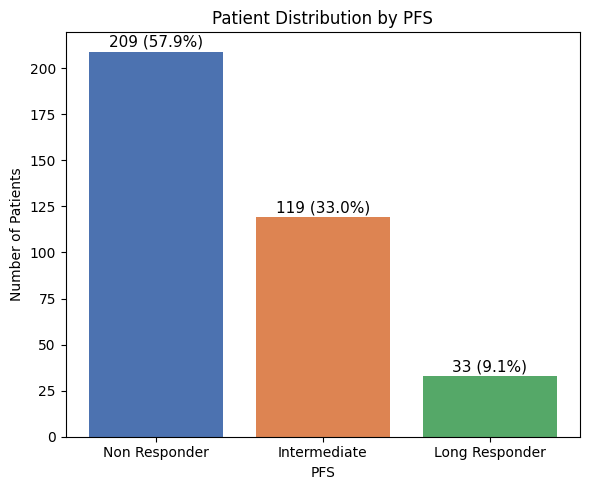

In [100]:
pfs_counts = clinical['pfs_label'].value_counts().sort_index()
pfs_pct = pfs_counts / pfs_counts.sum() * 100

fig, ax = plt.subplots(figsize=(6, 5))
bars = ax.bar(pfs_counts.index.astype(str), pfs_counts.values, color=['#4C72B0', '#DD8452', '#55A868'])

for bar, count, pct in zip(bars, pfs_counts.values, pfs_pct.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
            f'{count} ({pct:.1f}%)', ha='center', va='bottom', fontsize=11)

ax.set_xlabel('PFS')
ax.set_ylabel('Number of Patients')
ax.set_title('Patient Distribution by PFS')
ax.set_xticks(range(len(pfs_counts)))
ax.set_xticklabels(['Non Responder', 'Intermediate', 'Long Responder'])
plt.tight_layout()
plt.show()

## Numerical features

In [101]:
# num_cols = clinical.select_dtypes(include='number').columns
# cat_cols = clinical.select_dtypes(exclude='number').columns
num_cols = ['age']
cat_cols = ['pfs_label', 'sex', 'AJCC_stage', 'M_stage', 'LDH', 'drug', 'BOR', 'BRAF_mut', 'brain_metastasis', 'pre_MAPKi_treatment', 'source']
print(num_cols)
print(cat_cols)

['age']
['pfs_label', 'sex', 'AJCC_stage', 'M_stage', 'LDH', 'drug', 'BOR', 'BRAF_mut', 'brain_metastasis', 'pre_MAPKi_treatment', 'source']


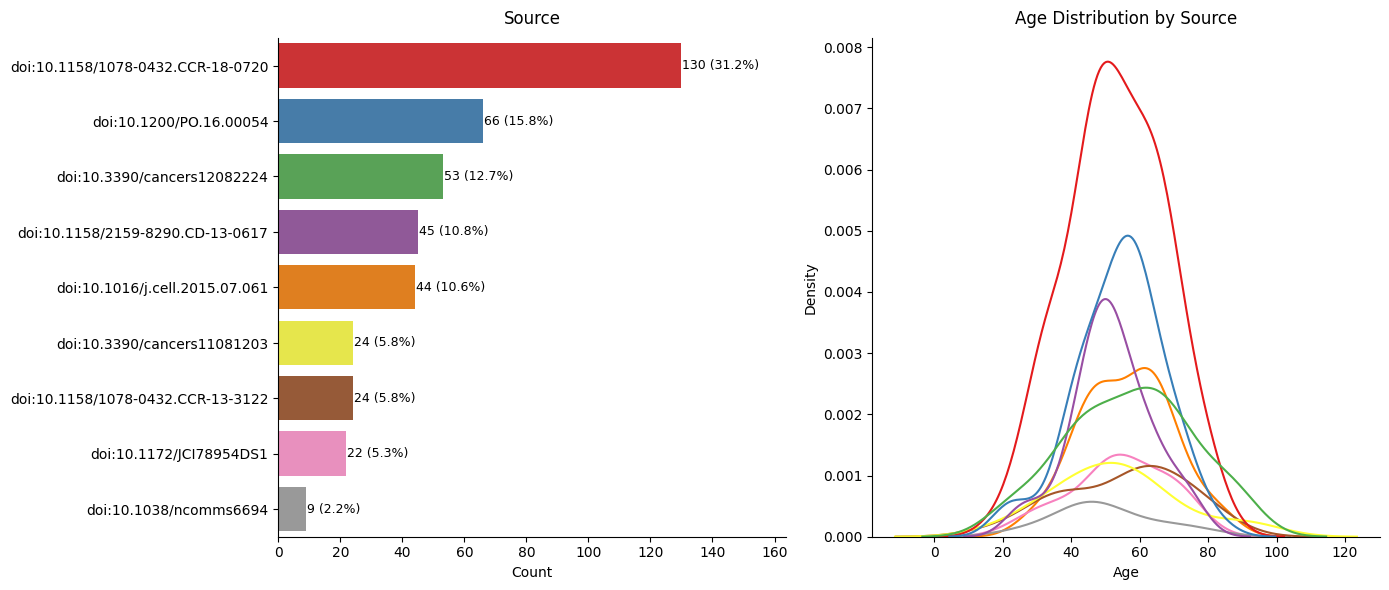

In [102]:
sources = clinical["source"].dropna().unique()
palette = dict(zip(clinical["source"].value_counts().index, sns.color_palette("Set1", len(sources))))

fig, axes = plt.subplots(1, 2, figsize=(14, max(len(sources) * 0.5 + 1.5, 4)))

# Left: count per source
order = clinical["source"].value_counts().index
total = clinical["source"].notna().sum()
sns.countplot(y="source", data=clinical, order=order, ax=axes[0], hue="source", palette=palette)
for p in axes[0].patches:
    count = int(p.get_width())
    if count > 0:
        axes[0].annotate(f"{count} ({100*count/total:.1f}%)",
                         (p.get_width() + 0.3, p.get_y() + p.get_height() / 2),
                         ha="left", va="center", fontsize=9)
axes[0].set_title("Source", fontsize=12, pad=10)
axes[0].set_xlabel("Count")
axes[0].set_ylabel("")
axes[0].set_xlim(0, axes[0].get_xlim()[1] * 1.2)
axes[0].spines[["top", "right"]].set_visible(False)

# Right: age distribution by source
sns.kdeplot(clinical, x="age", hue="source", ax=axes[1], palette=palette, legend=False)
axes[1].set_title("Age Distribution by Source", fontsize=12, pad=10)
axes[1].set_xlabel("Age")
axes[1].set_ylabel("Density")
axes[1].spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

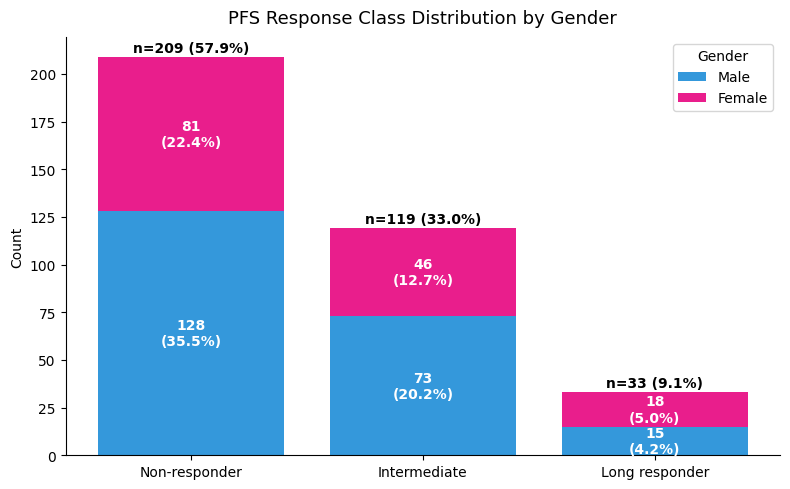

sex             female  male
Response                    
Non-responder       81   128
Intermediate        46    73
Long responder      18    15


In [103]:
label_names = {0.0: "Non-responder", 1.0: "Intermediate", 2.0: "Long responder"}
order = ["Non-responder", "Intermediate", "Long responder"]

plot_df = clinical.dropna(subset=["pfs_label"]).copy()
plot_df["Response"] = plot_df["pfs_label"].map(label_names)

counts = plot_df.groupby(["Response", "sex"]).size().unstack(fill_value=0).reindex(order)
total = counts.values.sum()

fig, ax = plt.subplots(figsize=(8, 5))

bars_male = ax.bar(order, counts["male"], color="#3498db", label="Male")
bars_female = ax.bar(order, counts["female"], bottom=counts["male"], color="#e91e8c", label="Female")

# Annotate male segments
for bar, val in zip(bars_male, counts["male"]):
    if val > 0:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() / 2,
                f"{val}\n({100*val/total:.1f}%)", ha="center", va="center", fontsize=10, color="white", fontweight="bold")

# Annotate female segments
for bar, m_val, f_val in zip(bars_female, counts["male"], counts["female"]):
    if f_val > 0:
        ax.text(bar.get_x() + bar.get_width() / 2, m_val + f_val / 2,
                f"{f_val}\n({100*f_val/total:.1f}%)", ha="center", va="center", fontsize=10, color="white", fontweight="bold")

# Total on top with percentage of whole
for i, (m, f) in enumerate(zip(counts["male"], counts["female"])):
    ax.text(i, m + f + 1, f"n={m+f} ({100*(m+f)/total:.1f}%)", ha="center", va="bottom", fontsize=10, fontweight="bold")

ax.set_title("PFS Response Class Distribution by Gender", fontsize=13, pad=10)
ax.set_xlabel("")
ax.set_ylabel("Count")
ax.legend(title="Gender")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

print(plot_df.groupby(["Response", "sex"]).size().unstack().reindex(order))

## Categorical features

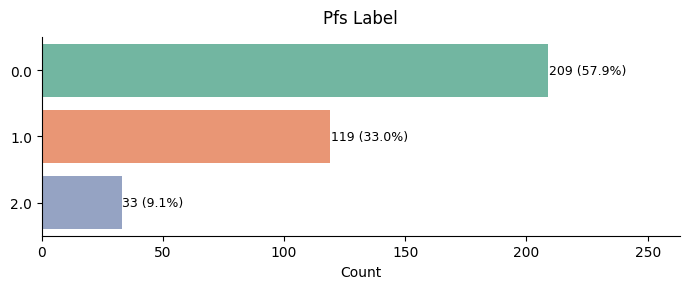

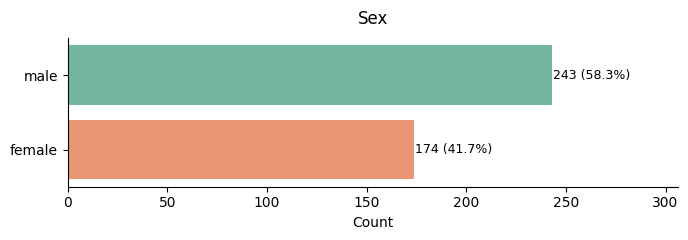

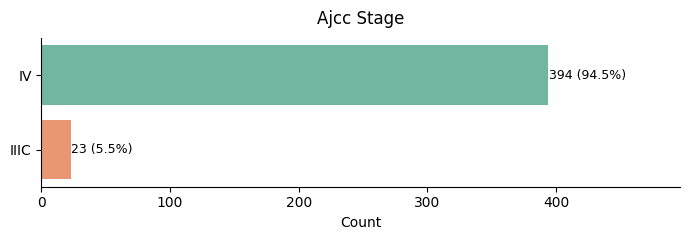

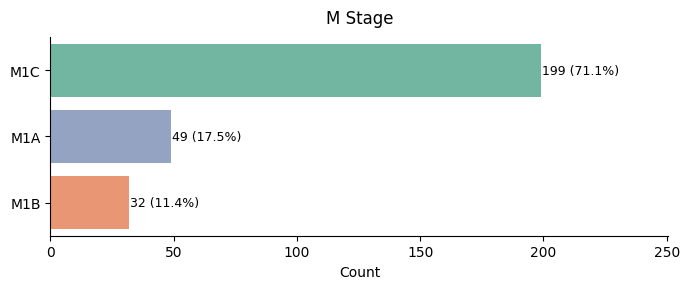

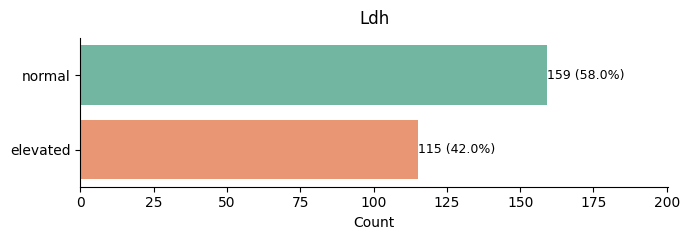

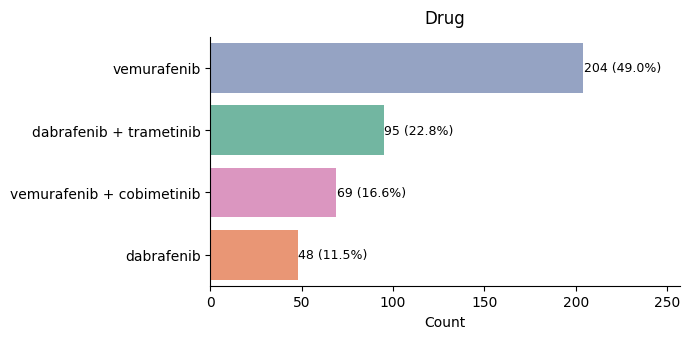

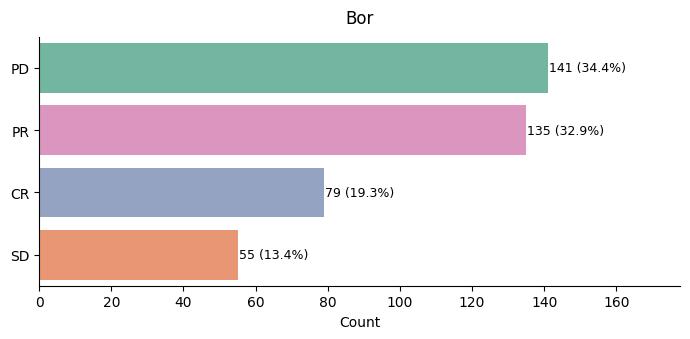

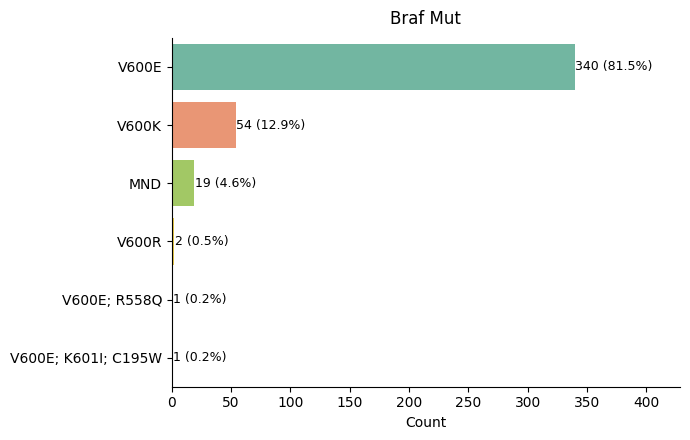

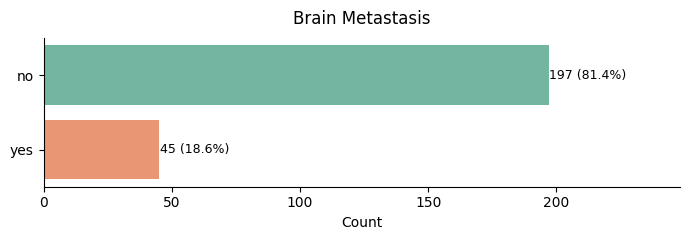

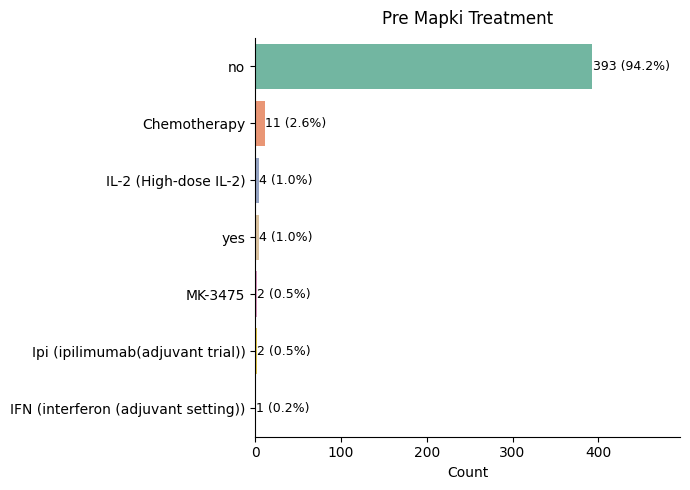

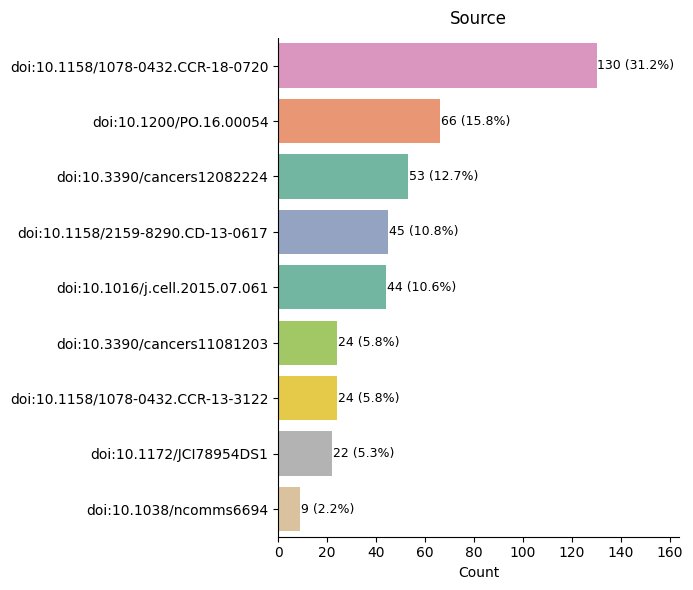

In [104]:
cat_features = [c for c in cat_cols]

for col in cat_features:
    order = clinical[col].value_counts().index
    total = clinical[col].notna().sum()

    fig, ax = plt.subplots(figsize=(7, len(order) * 0.5 + 1.5))
    sns.countplot(y=col, data=clinical, order=order, ax=ax, hue=col, palette="Set2", legend=False)

    for p in ax.patches:
        count = int(p.get_width())
        if count > 0:
            ax.annotate(f"{count} ({100*count/total:.1f}%)",
                        (p.get_width() + 0.3, p.get_y() + p.get_height() / 2),
                        ha="left", va="center", fontsize=9)

    ax.set_title(col.replace("_", " ").title(), fontsize=12, pad=10)
    ax.set_xlabel("Count")
    ax.set_ylabel("")
    ax.set_xlim(0, ax.get_xlim()[1] * 1.2)
    ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout()
    plt.show()

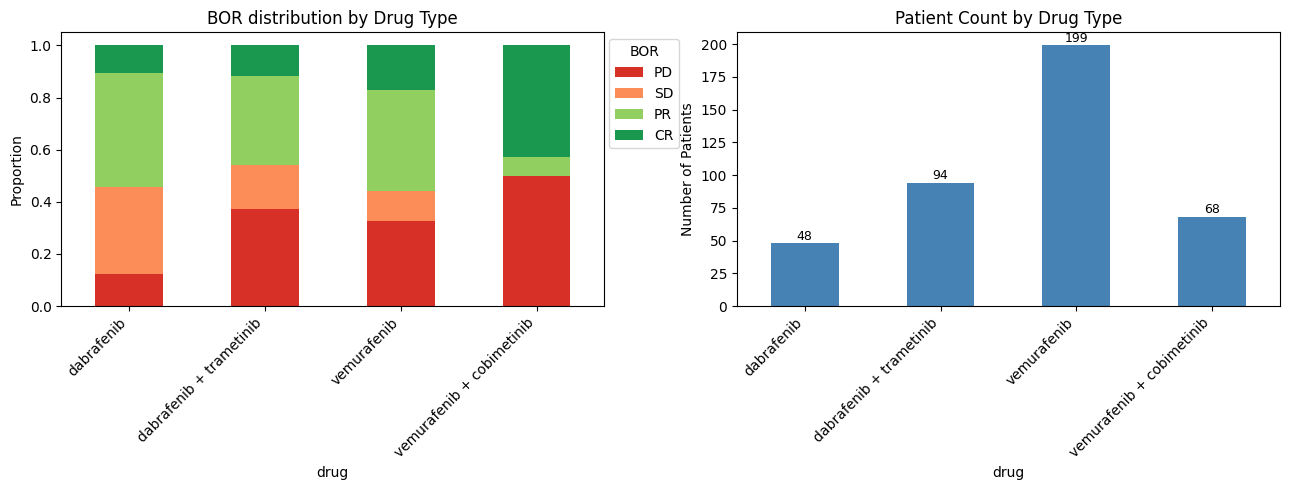

In [105]:
import pandas as pd
import matplotlib.pyplot as plt

df = clinical.copy()

# Drop NA/NE BOR values
df = df[df['BOR'].isin(['PD', 'SD', 'PR', 'CR'])]

# Define ordinal order (worst to best)
bor_order = ['PD', 'SD', 'PR', 'CR']

# Crosstab normalized by row, with explicit column order
ct_norm = pd.crosstab(df['drug'], df['BOR'], normalize='index')[bor_order]

# Color: red for bad response, green for good
colors = ['#d73027', '#fc8d59', '#91cf60', '#1a9850']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Left plot: BOR distribution
ct_norm.plot(kind='bar', stacked=True, color=colors, ax=ax1)
ax1.set_ylabel('Proportion')
ax1.set_title('BOR distribution by Drug Type')
ax1.tick_params(axis='x', rotation=45)
ax1.set_xticklabels(ax1.get_xticklabels(), ha='right')
ax1.legend(title='BOR', labels=bor_order, loc='upper right', bbox_to_anchor=(1.15, 1))

# Right plot: Patient count per drug
patient_counts = df.groupby('drug').size()
patient_counts.plot(kind='bar', ax=ax2, color='steelblue')
ax2.set_ylabel('Number of Patients')
ax2.set_title('Patient Count by Drug Type')
ax2.tick_params(axis='x', rotation=45)
ax2.set_xticklabels(ax2.get_xticklabels(), ha='right')
for i, v in enumerate(patient_counts):
    ax2.text(i, v + 0.5, str(v), ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()


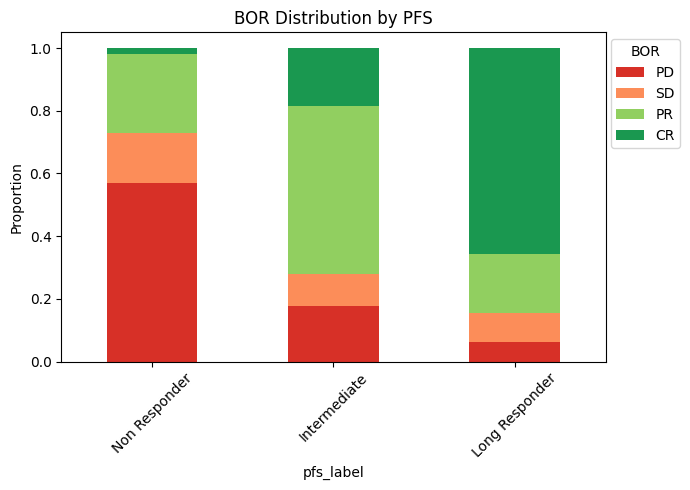

In [106]:
ct_pfs = pd.crosstab(clinical['pfs_label'], clinical['BOR'])
ct_pfs_norm = ct_pfs[bor_order].div(ct_pfs.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(7, 5))
ct_pfs_norm.plot(kind='bar', stacked=True, color=colors, ax=ax)
ax.set_ylabel('Proportion')
ax.set_title('BOR Distribution by PFS')
ax.tick_params(axis='x', rotation=45)
ax.set_xticklabels(['Non Responder', 'Intermediate', 'Long Responder'])
ax.legend(title='BOR', labels=bor_order, loc='upper right', bbox_to_anchor=(1.15, 1))
plt.tight_layout()
plt.show()


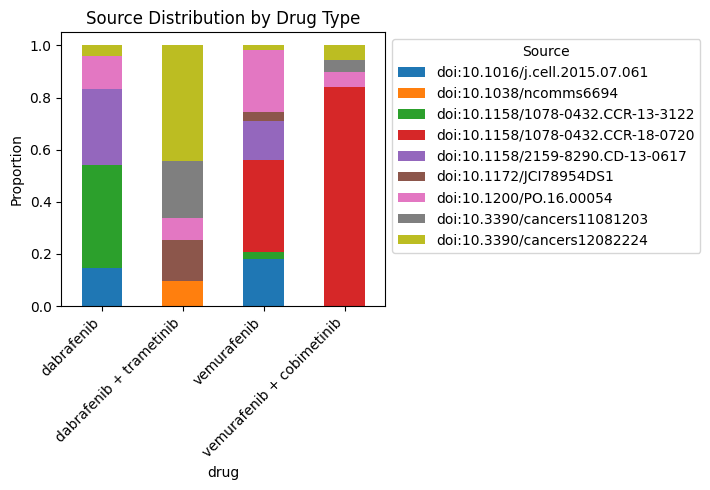

In [107]:
ct_drug = pd.crosstab(clinical['drug'], clinical['source'])
ct_drug_norm = ct_drug.div(ct_drug.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(6, 5))
ct_drug_norm.plot(kind='bar', stacked=True, ax=ax)
ax.set_ylabel('Proportion')
ax.set_title('Source Distribution by Drug Type')
ax.tick_params(axis='x', rotation=45)
ax.set_xticklabels(ax.get_xticklabels(), ha='right')
ax.legend(title='Source', loc='upper left', bbox_to_anchor=(1.0, 1.0))
plt.tight_layout()
plt.subplots_adjust(right=0.65)
plt.show()

In [108]:
from scipy.stats import chi2_contingency

ct_raw = pd.crosstab(df['drug'], df['BOR'])
chi2, p, dof, expected = chi2_contingency(ct_raw)
print(f'Chi2={chi2:.3f}, p={p:.4f}, dof={dof}')

Chi2=78.316, p=0.0000, dof=9


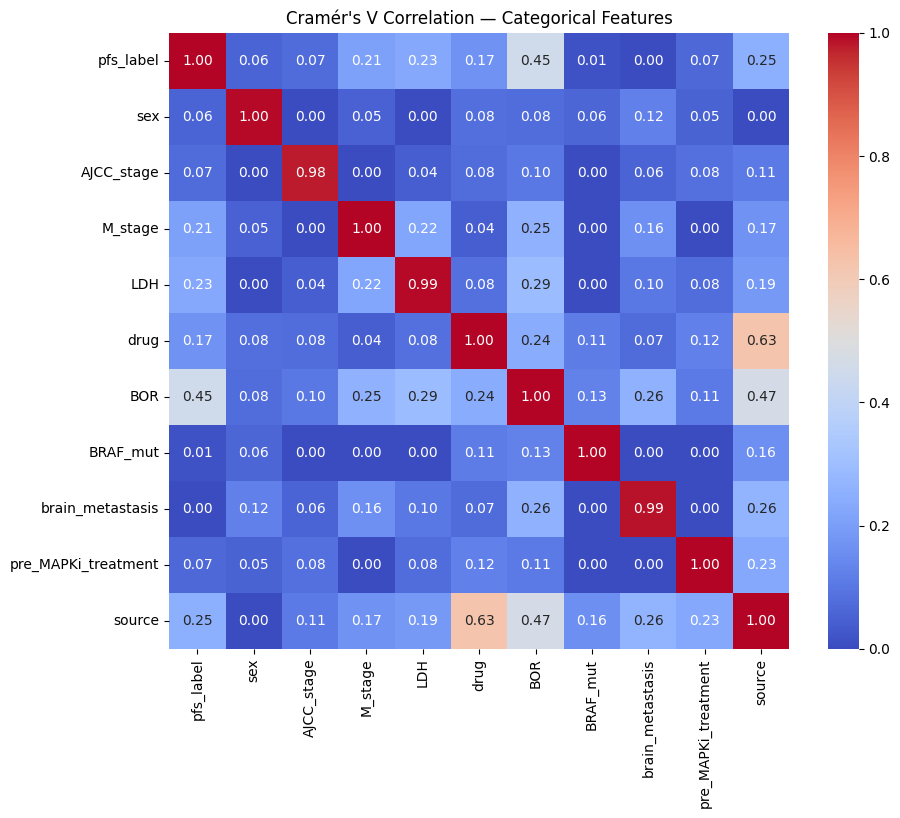

In [109]:
from scipy.stats import chi2_contingency
import numpy as np

def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    r, k = confusion_matrix.shape
    if min(k - 1, r - 1) == 0:
        return 0.0
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    # Bias-corrected
    phi2corr = max(0, phi2 - (k-1)*(r-1)/(n-1))
    kcorr = k - (k-1)**2/(n-1)
    rcorr = r - (r-1)**2/(n-1)
    if min(kcorr-1, rcorr-1) <= 0:
        return 0.0
    return np.sqrt(phi2corr / min(kcorr-1, rcorr-1))

# cat_cols_excluded = [x for x in cat_cols if x not in ['source']]
cat_cols_excluded = cat_cols

# Build correlation matrix
corr_matrix = pd.DataFrame(index=cat_cols_excluded, columns=cat_cols_excluded)

for col1 in cat_cols_excluded:
    for col2 in cat_cols_excluded:
        corr_matrix.loc[col1, col2] = cramers_v(clinical[col1], clinical[col2])

corr_matrix = corr_matrix.astype(float)

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm",
            vmin=0, vmax=1)
plt.title("Cramér's V Correlation — Categorical Features")
plt.show()